# 모델 평가 시각화

**전제**: `05_train_lstm_improved2.ipynb` 실행 완료 후 `data/predictions.npz` 가 업데이트된 상태

| 시각화 | 설명 |
|--------|------|
| Performance Bar Chart | Accuracy / Precision / Recall / F1 비교 (랜덤 베이스라인 포함) |
| Per-Class F1 | Down / Up 클래스별 F1 분리 비교 |
| Model Agreement | 모델 합의 수에 따른 Up Precision vs Coverage |
| Confusion Matrix | 모델별 혼동 행렬 |
| Prediction Distribution | 모델별 상승/하락 예측 비율 |


In [1]:
# [STEP 1] Google Drive 마운트 & 경로 설정
import os

DRIVE_PROJECT_PATH = "/content/drive/MyDrive/뉴스크롤링"

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = DRIVE_PROJECT_PATH
    print(f"[Drive 마운트 완료] BASE_DIR={BASE_DIR}")
except Exception:
    BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
    print(f"[로컬 환경] BASE_DIR={BASE_DIR}")

DATA_DIR   = os.path.join(BASE_DIR, "")
RESULT_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

pred_path = os.path.join(DATA_DIR, "predictions.npz")
print(f"predictions.npz 존재: {os.path.exists(pred_path)}")

Mounted at /content/drive
[Drive 마운트 완료] BASE_DIR=/content/drive/MyDrive/뉴스크롤링
predictions.npz 존재: True


In [2]:
# [STEP 2] 라이브러리 & matplotlib 한글 설정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

# Colab 한글 폰트 설정
try:
    import subprocess
    subprocess.run(["apt-get", "install", "-y", "-q", "fonts-nanum"], check=True,
                   capture_output=True)
    fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'
    print("한글 폰트 설정 완료 (NanumGothic)")
except Exception:
    print("한글 폰트 설치 실패 → 기본 폰트 사용")

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

한글 폰트 설정 완료 (NanumGothic)


In [ ]:
# [STEP 3] predictions.npz 로드
assert os.path.exists(pred_path), (
    f"predictions.npz 없음: {pred_path}\n"
    "05_train_lstm_improved2.ipynb 를 먼저 완료해주세요."
)

pred_data = np.load(pred_path)
y_test    = pred_data["y_test"]

MODEL_NAMES = [n for n in ["arima", "lstm", "transformer", "lgb"]
               if n in pred_data.files]

# LightGBM 확률값 (threshold 분석용)
lgb_probs   = pred_data["lgb_probs"] if "lgb_probs" in pred_data.files else None

print(f"로드 완료: {pred_path}")
print(f"총 샘플 수: {len(y_test):,}")
print(f"실제 Up 비율: {y_test.mean():.3f}")
print(f"포함된 모델: {MODEL_NAMES}")
print()
for name in MODEL_NAMES:
    preds = pred_data[name]
    print(f"  {name.upper():12s} Up 예측 비율: {preds.mean():.3f}  "
          f"(Down={(preds==0).sum():,} / Up={(preds==1).sum():,})")


In [4]:
# [STEP 4] 모델별 성능 지표 계산
rows = []
for name in MODEL_NAMES:
    y_pred = pred_data[name]
    f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)
    rows.append({
        "Model":      name.upper(),
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Precision":  precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall":     recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 (macro)":    f1_score(y_test, y_pred, average="macro",    zero_division=0),
        "F1 Down":    f1_per_class[0] if len(f1_per_class) > 0 else 0.0,
        "F1 Up":      f1_per_class[1] if len(f1_per_class) > 1 else 0.0,
        "Up Ratio":   float(y_pred.mean()),
    })

df_metrics = pd.DataFrame(rows)
display(df_metrics.style
    .format({c: "{:.4f}" for c in df_metrics.columns if c != "Model"})
    .highlight_max(subset=["Accuracy", "F1 (macro)", "F1 Up"], color="#d4edda")
    .set_caption("Model Performance Summary")
)

,Model,Accuracy,Precision,Recall,F1 (weighted),F1 (macro),F1 Down,F1 Up,Up Ratio
0,LSTM,0.5109,0.5047,0.5109,0.5002,0.4956,0.5834,0.4078,0.3523


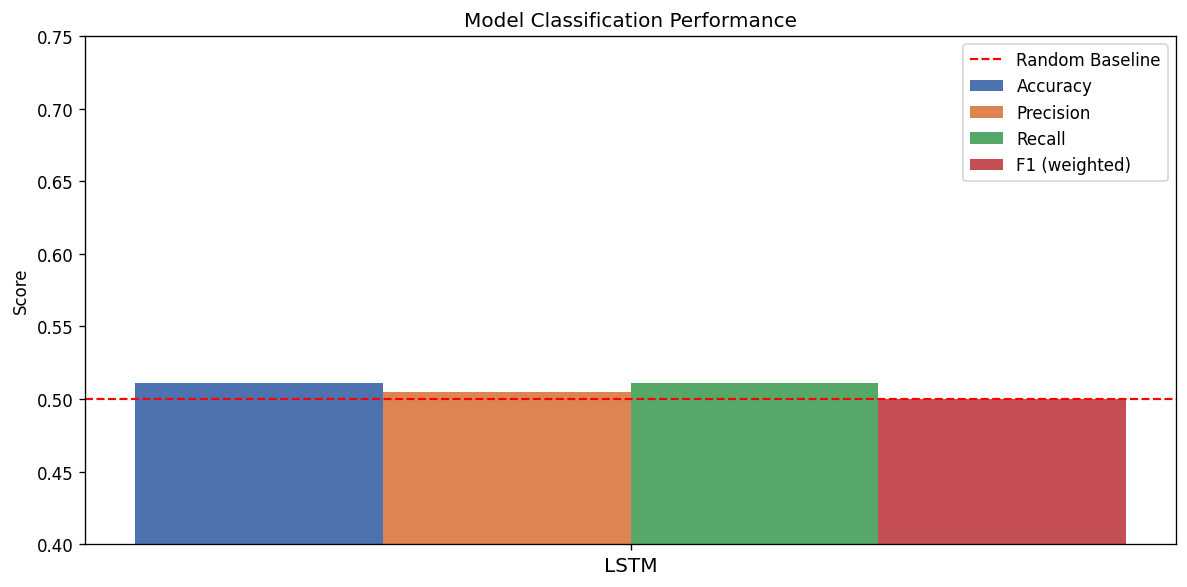

저장: /content/drive/MyDrive/뉴스크롤링/results/01_performance_bar.png


In [5]:
# [PLOT 1] Accuracy / Precision / Recall / F1 비교 막대그래프
metric_cols = ["Accuracy", "Precision", "Recall", "F1 (weighted)"]
x     = np.arange(len(df_metrics))
width = 0.18
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (col, color) in enumerate(zip(metric_cols, colors)):
    ax.bar(x + (i - 1.5) * width, df_metrics[col], width, label=col, color=color)

ax.axhline(0.5, color="red", linestyle="--", linewidth=1.3, label="Random Baseline")
ax.set_xticks(x)
ax.set_xticklabels(df_metrics["Model"], fontsize=12)
ax.set_ylim(0.4, 0.75)
ax.set_ylabel("Score")
ax.set_title("Model Classification Performance")
ax.legend()
plt.tight_layout()

save_path = os.path.join(RESULT_DIR, "01_performance_bar.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {save_path}")

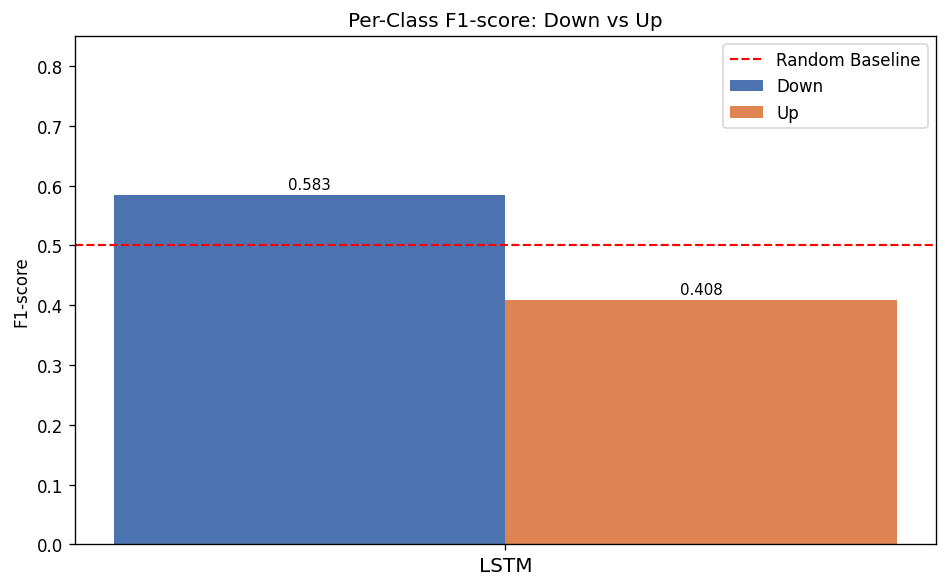

저장: /content/drive/MyDrive/뉴스크롤링/results/02_per_class_f1.png


In [6]:
# [PLOT 2] Down / Up 클래스별 F1 분리 비교
x     = np.arange(len(df_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_down = ax.bar(x - width / 2, df_metrics["F1 Down"], width, label="Down", color="#4C72B0")
bars_up   = ax.bar(x + width / 2, df_metrics["F1 Up"],   width, label="Up",   color="#DD8452")

for bar in list(bars_down) + list(bars_up):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.006,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.axhline(0.5, color="red", linestyle="--", linewidth=1.3, label="Random Baseline")
ax.set_xticks(x)
ax.set_xticklabels(df_metrics["Model"], fontsize=12)
ax.set_ylim(0, 0.85)
ax.set_ylabel("F1-score")
ax.set_title("Per-Class F1-score: Down vs Up")
ax.legend()
plt.tight_layout()

save_path = os.path.join(RESULT_DIR, "02_per_class_f1.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {save_path}")

/tmp/ipykernel_2841/144431523.py:42: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2841/144431523.py:42: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2841/144431523.py:42: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2841/144431523.py:42: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2841/144431523.py:42: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2841/144431523.py:42: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2841/144431523.py:45: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_

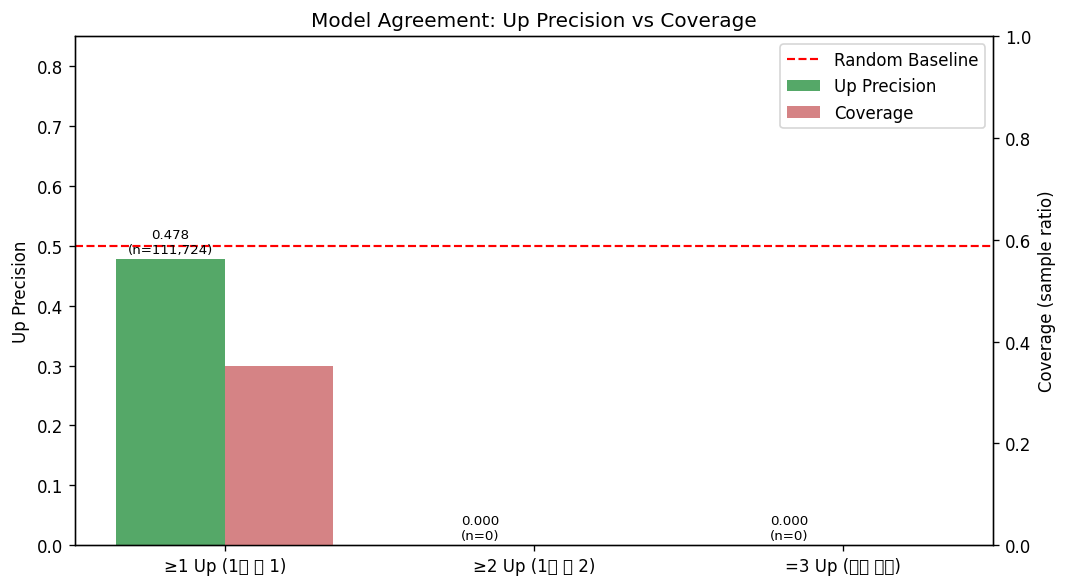

저장: /content/drive/MyDrive/뉴스크롤링/results/03_model_agreement.png


In [7]:
# [PLOT 3] 모델 합의 분석 — Up Precision vs Coverage
agree_counts = sum(pred_data[n] for n in MODEL_NAMES)

labels    = [f"≥1 Up ({len(MODEL_NAMES)}개 중 1)",
             f"≥2 Up ({len(MODEL_NAMES)}개 중 2)",
             f"=3 Up (전체 동의)"]
thresholds = [1, 2, 3]

precisions, coverages, sample_counts = [], [], []
for t in thresholds:
    mask = agree_counts >= t
    n    = int(mask.sum())
    sample_counts.append(n)
    precisions.append(float(y_test[mask].mean()) if n > 0 else 0.0)
    coverages.append(float(mask.mean()))

x     = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bars = ax1.bar(x - width / 2, precisions, width, label="Up Precision", color="#55A868")
ax2.bar(x + width / 2, coverages, width, label="Coverage", color="#C44E52", alpha=0.7)

for bar, val, n in zip(bars, precisions, sample_counts):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.3f}\n(n={n:,})", ha="center", va="bottom", fontsize=8)

ax1.axhline(0.5, color="red", linestyle="--", linewidth=1.3, label="Random Baseline")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylim(0, 0.85)
ax1.set_ylabel("Up Precision")
ax2.set_ylim(0, 1)
ax2.set_ylabel("Coverage (sample ratio)")
ax1.set_title("Model Agreement: Up Precision vs Coverage")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
plt.tight_layout()

save_path = os.path.join(RESULT_DIR, "03_model_agreement.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {save_path}")

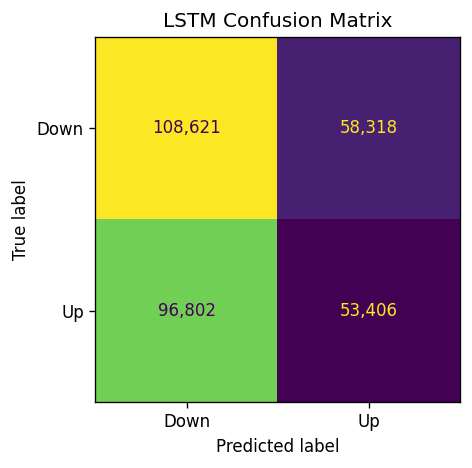

저장: /content/drive/MyDrive/뉴스크롤링/results/04_confusion_matrices.png


In [8]:
# [PLOT 4] 모델별 Confusion Matrix
n_models = len(MODEL_NAMES)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, MODEL_NAMES):
    cm   = confusion_matrix(y_test, pred_data[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"])
    disp.plot(values_format=",d", ax=ax, colorbar=False)
    ax.set_title(f"{name.upper()} Confusion Matrix", fontsize=12)

plt.tight_layout()
save_path = os.path.join(RESULT_DIR, "04_confusion_matrices.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {save_path}")

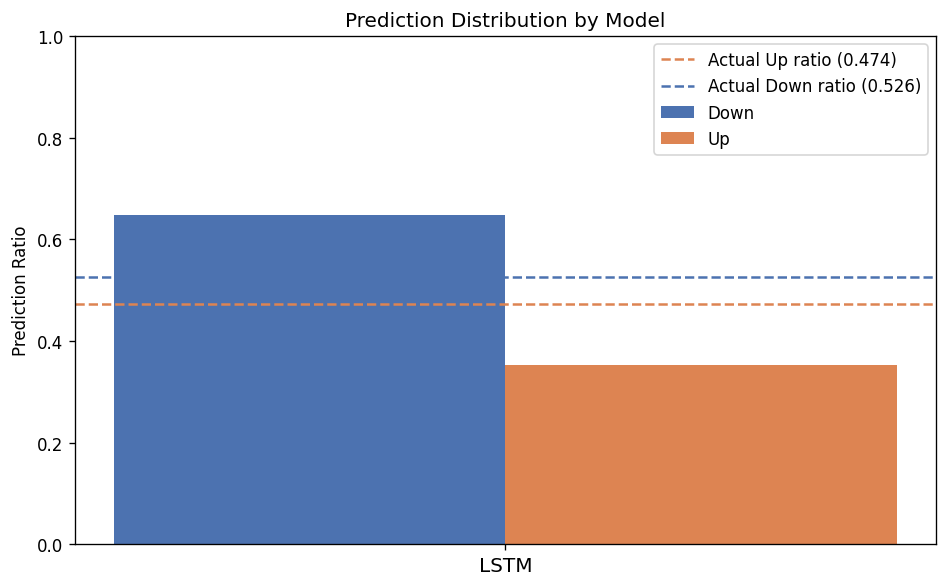

저장: /content/drive/MyDrive/뉴스크롤링/results/05_prediction_distribution.png


In [9]:
# [PLOT 5] 모델별 상승/하락 예측 비율 (실제값 기준선 포함)
actual_up_ratio = float(y_test.mean())

model_labels = [n.upper() for n in MODEL_NAMES]
down_ratios  = [(pred_data[n] == 0).mean() for n in MODEL_NAMES]
up_ratios    = [(pred_data[n] == 1).mean() for n in MODEL_NAMES]

x     = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, down_ratios, width, label="Down", color="#4C72B0")
ax.bar(x + width / 2, up_ratios,   width, label="Up",   color="#DD8452")

ax.axhline(actual_up_ratio, color="#DD8452", linestyle="--", linewidth=1.5,
           label=f"Actual Up ratio ({actual_up_ratio:.3f})")
ax.axhline(1 - actual_up_ratio, color="#4C72B0", linestyle="--", linewidth=1.5,
           label=f"Actual Down ratio ({1-actual_up_ratio:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=12)
ax.set_ylim(0, 1)
ax.set_ylabel("Prediction Ratio")
ax.set_title("Prediction Distribution by Model")
ax.legend()
plt.tight_layout()

save_path = os.path.join(RESULT_DIR, "05_prediction_distribution.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {save_path}")

In [10]:
# [STEP 5] 결과 CSV 저장
csv_path = os.path.join(RESULT_DIR, "model_metrics.csv")
df_metrics.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"성능 요약 저장: {csv_path}")
print()
print("=== 저장된 시각화 파일 ===")
for f in sorted(os.listdir(RESULT_DIR)):
    if f.endswith(".png"):
        print(f"  {f}")

성능 요약 저장: /content/drive/MyDrive/뉴스크롤링/results/model_metrics.csv

=== 저장된 시각화 파일 ===
  01_performance_bar.png
  02_per_class_f1.png
  03_model_agreement.png
  04_confusion_matrices.png
  05_prediction_distribution.png


---
## LightGBM 전용 분석


In [ ]:
# [PLOT 6] LightGBM Threshold 분석 (Precision / Recall / F1 / Coverage)
from sklearn.metrics import precision_score, recall_score, f1_score

if lgb_probs is None:
    print("[주의] lgb_probs 없음 → 05_train_lstm_improved2.ipynb 재실행 필요")
else:
    thresholds = np.arange(0.35, 0.76, 0.02)
    rows_thr = []
    for t in thresholds:
        p_t  = (lgb_probs > t).astype(int)
        n_up = int(p_t.sum())
        if n_up == 0:
            rows_thr.append(dict(threshold=round(t,2), precision=0, recall=0,
                                 f1_up=0, coverage=0, n_up=0))
            continue
        rows_thr.append(dict(
            threshold = round(t, 2),
            precision = precision_score(y_test.astype(int), p_t, pos_label=1, zero_division=0),
            recall    = recall_score(y_test.astype(int),    p_t, pos_label=1, zero_division=0),
            f1_up     = f1_score(y_test.astype(int),        p_t, pos_label=1, zero_division=0),
            coverage  = float(p_t.mean()),
            n_up      = n_up,
        ))

    df_thr_lgb = pd.DataFrame(rows_thr)
    print(df_thr_lgb.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()

    ax1.plot(df_thr_lgb["threshold"], df_thr_lgb["precision"], "o-",
             color="#DD8452", linewidth=2, label="Up Precision")
    ax1.plot(df_thr_lgb["threshold"], df_thr_lgb["recall"],    "s--",
             color="#4C72B0", linewidth=2, label="Up Recall")
    ax1.plot(df_thr_lgb["threshold"], df_thr_lgb["f1_up"],     "^:",
             color="#55A868", linewidth=2, label="Up F1")
    ax2.bar(df_thr_lgb["threshold"], df_thr_lgb["coverage"],
            width=0.015, alpha=0.25, color="gray", label="Coverage")

    best_row = df_thr_lgb.loc[df_thr_lgb["f1_up"].idxmax()]
    ax1.axvline(best_row["threshold"], color="purple", linestyle=":", linewidth=1.5,
                label=f"Best F1 @ {best_row['threshold']:.2f}")
    ax1.axhline(0.5, color="red", linestyle="--", linewidth=1.2, alpha=0.7, label="Random")

    ax1.set_xlabel("Threshold", fontsize=12)
    ax1.set_ylabel("Score", fontsize=12)
    ax1.set_ylim(0, 0.85)
    ax2.set_ylim(0, 1.2)
    ax2.set_ylabel("Coverage", fontsize=12)
    ax1.set_title("LightGBM: Up Precision / Recall / F1 vs Threshold", fontsize=13)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="center left", fontsize=9)
    plt.tight_layout()

    save_path = os.path.join(RESULT_DIR, "06_lgb_threshold.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {save_path}")
    print(f"\n최적 F1 threshold: {best_row['threshold']:.2f}  "
          f"(precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}, "
          f"f1={best_row['f1_up']:.3f}, coverage={best_row['coverage']:.3f})")


In [ ]:
# [PLOT 7] Walk-forward 월별 성능 추이
wf_path = os.path.join(RESULT_DIR, "lgb_walkforward.csv")

if not os.path.exists(wf_path):
    print(f"[주의] {wf_path} 없음 → 05_train_lstm_improved2.ipynb 재실행 필요")
else:
    df_wf = pd.read_csv(wf_path)
    print(df_wf.to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 5))

    x = np.arange(len(df_wf))
    ax.plot(x, df_wf["precision"], "o-",  color="#DD8452", linewidth=2, label="Precision")
    ax.plot(x, df_wf["recall"],    "s--", color="#4C72B0", linewidth=2, label="Recall")
    ax.plot(x, df_wf["f1_up"],     "^:",  color="#55A868", linewidth=2, label="F1 Up")
    ax.plot(x, df_wf["accuracy"],  "D-.", color="#8172B2", linewidth=2, label="Accuracy")

    ax.axhline(0.5, color="red", linestyle="--", linewidth=1.2, alpha=0.7, label="Random (0.50)")
    ax.fill_between(x, df_wf["precision"] - 0.02, df_wf["precision"] + 0.02,
                    alpha=0.1, color="#DD8452")

    # 평균선
    for col, color in [("precision","#DD8452"),("f1_up","#55A868")]:
        ax.axhline(df_wf[col].mean(), color=color, linestyle=":", linewidth=1.5, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(df_wf["fold"], rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0.3, 0.75)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("LightGBM Walk-forward CV: 월별 성능 추이", fontsize=13)
    ax.legend(loc="upper right", fontsize=9)

    # n_train 보조 정보
    ax2 = ax.twinx()
    ax2.bar(x, df_wf["n_test"], width=0.4, alpha=0.15, color="gray", label="n_test")
    ax2.set_ylabel("Test 샘플 수", fontsize=10, color="gray")
    ax2.tick_params(axis="y", labelcolor="gray")

    plt.tight_layout()
    save_path = os.path.join(RESULT_DIR, "07_lgb_walkforward.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {save_path}")

    mean_prec = df_wf["precision"].mean()
    std_prec  = df_wf["precision"].std()
    print(f"\nWalk-forward 평균 Precision: {mean_prec:.3f} ± {std_prec:.3f}")
    print(f"Walk-forward 평균 F1 Up:      {df_wf['f1_up'].mean():.3f} ± {df_wf['f1_up'].std():.3f}")
    print(f"성능 일관성 (std 낮을수록 안정적): precision std={std_prec:.3f}")


In [ ]:
# [PLOT 8] LSTM vs LightGBM 직접 비교 (threshold별 Precision 곡선)
lstm_probs = pred_data["lstm_probs"] if "lstm_probs" in pred_data.files else None

if lstm_probs is None or lgb_probs is None:
    print("[주의] lstm_probs 또는 lgb_probs 없음 → 05_train_lstm_improved2.ipynb 재실행 필요")
else:
    thresholds = np.arange(0.35, 0.76, 0.01)
    y = y_test.astype(int)

    def threshold_curve(probs):
        rows = []
        for t in thresholds:
            p = (probs > t).astype(int)
            if p.sum() == 0:
                rows.append((t, 0, 0, 0, 0))
                continue
            rows.append((
                t,
                precision_score(y, p, pos_label=1, zero_division=0),
                recall_score(y,    p, pos_label=1, zero_division=0),
                f1_score(y,        p, pos_label=1, zero_division=0),
                float(p.mean()),
            ))
        return pd.DataFrame(rows, columns=["threshold","precision","recall","f1_up","coverage"])

    df_lstm_c = threshold_curve(lstm_probs)
    df_lgb_c  = threshold_curve(lgb_probs)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, metric, title in zip(axes,
                                  ["precision", "recall", "f1_up"],
                                  ["Up Precision", "Up Recall", "Up F1"]):
        ax.plot(df_lstm_c["threshold"], df_lstm_c[metric], "-",
                color="#4C72B0", linewidth=2, label="LSTM")
        ax.plot(df_lgb_c["threshold"],  df_lgb_c[metric],  "--",
                color="#DD8452", linewidth=2, label="LightGBM")
        ax.axhline(0.5, color="red", linestyle=":", linewidth=1.2, alpha=0.7, label="Random")
        ax.set_xlabel("Threshold")
        ax.set_ylabel(metric)
        ax.set_title(title)
        ax.set_ylim(0.2, 0.8)
        ax.legend(fontsize=9)

    plt.suptitle("LSTM vs LightGBM: Threshold별 Up 성능 비교", fontsize=13)
    plt.tight_layout()

    save_path = os.path.join(RESULT_DIR, "08_lstm_vs_lgb_comparison.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {save_path}")

    # 최적 임계값 정리
    print("\n[최적 threshold 요약]")
    for name, df_c in [("LSTM", df_lstm_c), ("LightGBM", df_lgb_c)]:
        best = df_c.loc[df_c["f1_up"].idxmax()]
        print(f"  {name:10s}  best_threshold={best['threshold']:.2f}  "
              f"prec={best['precision']:.3f}  rec={best['recall']:.3f}  "
              f"f1={best['f1_up']:.3f}  coverage={best['coverage']:.3f}")


---
## 모의투자 시뮬레이션 (2026-02 ~ 2026-04)

LightGBM이 **Up**으로 예측한 종목을 t일 종가에 매수 → t+3거래일 종가에 청산하는 전략을 시뮬레이션합니다.

| 항목 | 내용 |
|---|---|
| 투자 기간 | 2026-02 ~ 2026-04 (test 구간) |
| 매수 조건 | lgb_prob > threshold인 종목 |
| 포지션 | 매일 Up 예측 종목에 동일 비중 투자 |
| 청산 | t+3 거래일 종가 |
| 벤치마크 | 전 종목 동일가중 평균 수익률 |

In [ ]:
# [MOCK 1] 데이터 로드 & 실제 3거래일 수익률 계산
import os
import numpy as np
import pandas as pd

# ── dataset9.npz 로드 (test_codes, test_dates) ──────────────────────────────
ds_path = os.path.join(DATA_DIR, "dataset9.npz")
assert os.path.exists(ds_path), f"dataset9.npz 없음: {ds_path}"

ds = np.load(ds_path, allow_pickle=True)
test_codes = ds["test_codes"]
test_dates = ds["test_dates"]
print(f"test 샘플 수: {len(test_codes):,}")
print(f"test 기간: {test_dates.min()} ~ {test_dates.max()}")

# ── ohlcv.csv 로드 ───────────────────────────────────────────────────────────
ohlcv_path = os.path.join(DATA_DIR, "ohlcv.csv")
assert os.path.exists(ohlcv_path), f"ohlcv.csv 없음: {ohlcv_path}"

df_ohlcv = pd.read_csv(ohlcv_path, parse_dates=["date"],
                       usecols=["date", "code", "close"])
df_ohlcv["code"] = df_ohlcv["code"].astype(str).str.zfill(6)
print(f"ohlcv.csv: {len(df_ohlcv):,}행, 기간: {df_ohlcv['date'].min().date()} ~ {df_ohlcv['date'].max().date()}")

# ── 예측 DataFrame 구성 ──────────────────────────────────────────────────────
assert lgb_probs is not None, "lgb_probs 없음 → 05_train_lstm_improved2.ipynb 재실행 필요"

df_pred = pd.DataFrame({
    "code":    pd.Series(test_codes).astype(str).str.zfill(6),
    "date":    pd.to_datetime(test_dates),
    "lgb_prob": lgb_probs,
    "actual_label": y_test.astype(int),
})

# ── t+3 거래일 계산 (벡터화) ─────────────────────────────────────────────────
trading_days = np.sort(df_ohlcv["date"].unique())
td_index = pd.Series(range(len(trading_days)), index=trading_days)

t_idx  = df_pred["date"].map(td_index)
t3_idx = t_idx + 3
valid  = t3_idx < len(trading_days)

df_pred["date_t3"] = pd.NaT
df_pred.loc[valid, "date_t3"] = trading_days[t3_idx[valid].astype(int)]
df_pred = df_pred.dropna(subset=["date_t3"])

# ── 실제 3거래일 수익률 계산 ─────────────────────────────────────────────────
close_map = df_ohlcv.set_index(["date", "code"])["close"]

def safe_return(row):
    try:
        c0 = close_map.at[(row["date"],    row["code"])]
        c3 = close_map.at[(row["date_t3"], row["code"])]
        return float(c3) / float(c0) - 1
    except KeyError:
        return np.nan

df_pred["actual_return"] = df_pred.apply(safe_return, axis=1)
df_pred = df_pred.dropna(subset=["actual_return"])

print(f"\n유효 샘플: {len(df_pred):,}")
print(f"평균 3일 수익률: {df_pred['actual_return'].mean()*100:.3f}%")
print(f"Up 예측 샘플(prob>0.5): {(df_pred['lgb_prob']>0.5).sum():,}")
df_pred.head(3)

In [ ]:
# [MOCK 2] 모의투자 시뮬레이션 & 시각화
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SIM_THRESHOLD = 0.55  # ★ 조정 가능 (0.50 ~ 0.65 권장)

# ── 날짜별 전략 수익률 계산 ──────────────────────────────────────────────────
rows_sim = []
for date, grp in df_pred.groupby("date"):
    up_picks  = grp[grp["lgb_prob"] > SIM_THRESHOLD]
    all_ret   = grp["actual_return"].mean()          # 벤치마크: 전종목 평균
    strat_ret = up_picks["actual_return"].mean() if len(up_picks) > 0 else 0.0
    rows_sim.append({
        "date":        date,
        "strat_return": strat_ret,
        "bench_return": all_ret,
        "n_picks":      len(up_picks),
        "total_stocks": len(grp),
    })

df_sim = pd.DataFrame(rows_sim).sort_values("date").reset_index(drop=True)

# ── 누적 수익률 ──────────────────────────────────────────────────────────────
# 각 날짜의 수익률은 t+3일 청산 기준 → 3거래일마다 자본이 회전
# 매일 Up 예측 종목 전체에 동일 비중 투자하는 전략 수익률을 단순 평균으로 근사
df_sim["cum_strat"] = (1 + df_sim["strat_return"]).cumprod() - 1
df_sim["cum_bench"] = (1 + df_sim["bench_return"]).cumprod() - 1

# ── 요약 통계 ────────────────────────────────────────────────────────────────
total_strat  = df_sim["cum_strat"].iloc[-1] * 100
total_bench  = df_sim["cum_bench"].iloc[-1] * 100
excess       = total_strat - total_bench
win_rate     = (df_sim["strat_return"] > df_sim["bench_return"]).mean() * 100
avg_picks    = df_sim["n_picks"].mean()
hit_rate     = (df_sim["strat_return"] > 0).mean() * 100

print(f"{'='*55}")
print(f"  LightGBM 모의투자 요약  (threshold={SIM_THRESHOLD})")
print(f"{'='*55}")
print(f"  기간          : {df_sim['date'].min().date()} ~ {df_sim['date'].max().date()}")
print(f"  거래일 수     : {len(df_sim)}일")
print(f"  전략 누적수익 : {total_strat:+.2f}%")
print(f"  벤치마크 수익 : {total_bench:+.2f}%")
print(f"  초과 수익     : {excess:+.2f}%p")
print(f"  벤치마크 초과 비율 : {win_rate:.1f}%")
print(f"  수익 발생일 비율   : {hit_rate:.1f}%")
print(f"  평균 일별 종목 수  : {avg_picks:.0f}개 / {df_sim['total_stocks'].mean():.0f}개")

# ── 시각화 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                         gridspec_kw={"height_ratios": [3, 1]})

# 상단: 누적 수익률 곡선
ax1 = axes[0]
ax1.plot(df_sim["date"], df_sim["cum_strat"] * 100,
         label=f"LightGBM 전략 (threshold={SIM_THRESHOLD})",
         color="#2196F3", linewidth=2)
ax1.plot(df_sim["date"], df_sim["cum_bench"] * 100,
         label="벤치마크 (전종목 동일가중)",
         color="#9E9E9E", linewidth=1.5, linestyle="--")
ax1.fill_between(df_sim["date"],
                 df_sim["cum_strat"] * 100,
                 df_sim["cum_bench"] * 100,
                 where=(df_sim["cum_strat"] >= df_sim["cum_bench"]),
                 alpha=0.15, color="#2196F3", label="초과 수익 구간")
ax1.fill_between(df_sim["date"],
                 df_sim["cum_strat"] * 100,
                 df_sim["cum_bench"] * 100,
                 where=(df_sim["cum_strat"] < df_sim["cum_bench"]),
                 alpha=0.15, color="#F44336", label="열위 구간")
ax1.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.set_title(f"LightGBM 모의투자 누적 수익률  "
              f"(전략 {total_strat:+.1f}%  /  벤치마크 {total_bench:+.1f}%  /  "
              f"초과 {excess:+.1f}%p)", fontsize=12)
ax1.set_ylabel("누적 수익률 (%)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 하단: 일별 Up 예측 종목 수
ax2 = axes[1]
ax2.bar(df_sim["date"], df_sim["n_picks"],
        color="#2196F3", alpha=0.6, width=0.8)
ax2.set_ylabel("Up 예측 종목 수")
ax2.set_title(f"일별 Up 예측 종목 수 (평균 {avg_picks:.0f}개)")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
save_path = os.path.join(RESULT_DIR, "09_mock_investment.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {save_path}")

# ── threshold별 성과 비교 표 ─────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  threshold별 모의투자 성과")
print(f"{'='*55}")
print(f"{'threshold':>10} {'전략수익':>9} {'벤치':>7} {'초과':>7} {'승률':>7} {'평균종목':>8}")
for thr in [0.45, 0.50, 0.55, 0.60, 0.65]:
    rows_t = []
    for date, grp in df_pred.groupby("date"):
        picks = grp[grp["lgb_prob"] > thr]
        bench_r = grp["actual_return"].mean()
        strat_r = picks["actual_return"].mean() if len(picks) > 0 else 0.0
        rows_t.append({"strat": strat_r, "bench": bench_r, "n": len(picks)})
    df_t = pd.DataFrame(rows_t)
    cum_s = ((1 + df_t["strat"]).prod() - 1) * 100
    cum_b = ((1 + df_t["bench"]).prod() - 1) * 100
    wr    = (df_t["strat"] > df_t["bench"]).mean() * 100
    avg_n = df_t["n"].mean()
    print(f"{thr:>10.2f} {cum_s:>+8.2f}% {cum_b:>+6.2f}% {cum_s-cum_b:>+6.2f}%p {wr:>6.1f}% {avg_n:>7.0f}개")